# Project 1: Automated Loan Approval Pipeline
## Tool: Alteryx Designer

### Overview
In this project, I built an automated workflow to process loan applications.
The goal was to:
1. Clean raw data (handle nulls and data types).
2. Calculate "Total Household Income" and "Loan-to-Income Ratios."
3. Automatically segment loan applications into **Approved** or **Manual Review** based on risk logic.

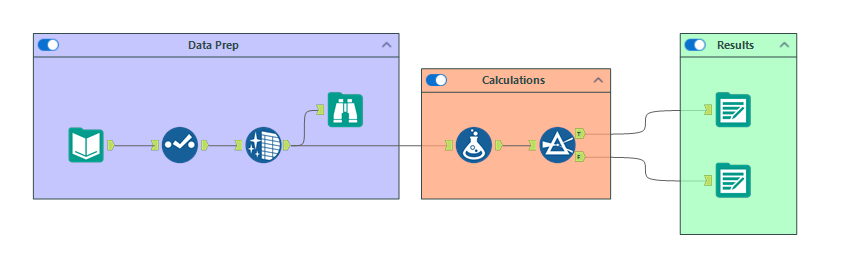

In [ ]:
from IPython.display import Image
Image(filename='Alteryx_Workflow_Project1.png', width=1200)

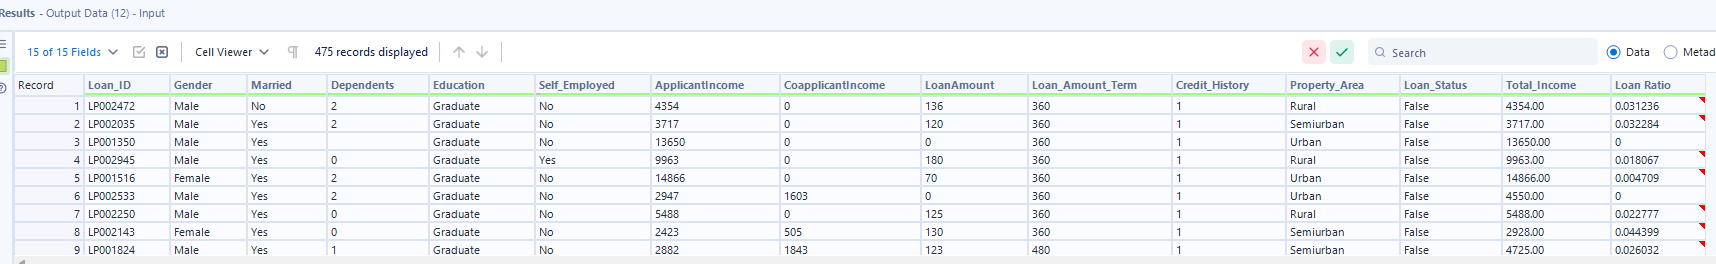

In [ ]:
from IPython.display import Image
Image(filename='Alteryx_Results_Project1.png', width=1600)

### Financial Engineering Logic
To determine loan eligibility, I created two custom metrics within the Alteryx Formula Tool:

1. **Total Household Income**:
   $$Total\_Income = Applicant\_Income + Coapplicant\_Income$$
   *Purpose: Captures the full repayment power of the household.*

2. **Loan-to-Income Ratio (LTI)**:
   $$LTI = \frac{Loan\_Amount}{Total\_Income}$$
   *Purpose: This creates a decimal ratio representing the size of the loan relative to annual earnings (e.g., 0.30 means the loan is 30% of their total income).*

**The "Safety" Rule:**
An application is automatically **Approved** only if it meets both criteria:
* **Credit History = 1.0** (The applicant has a clean credit record).
* **LTI Ratio < 0.35** (The requested loan amount is less than 35% of their total income).
Data Note: Understanding Credit History

**1.0 (Positive)**: Indicates a history of meeting financial obligations.

**0.0 (Negative)**: Indicates previous defaults or late payments.

By filtering for Credit_History = 1.0, we ensure the automated approval pipeline only accepts applicants with a proven track record of repayment.

*Note: Any applicant failing either of these checks is diverted to **Manual Review** for a secondary risk assessment.*

In [ ]:
import pandas as pd
# Load the file created in Alteryx
approved = pd.read_csv('Approved_Loans.csv')

# Show the first 5 rows to prove the "Total Income" column exists
approved.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Loan Ratio
0,LP002472,Male,No,2,Graduate,No,4354,0,136,360,1,Rural,False,4354.0,0.031236
1,LP002035,Male,Yes,2,Graduate,No,3717,0,120,360,1,Semiurban,False,3717.0,0.032284
2,LP001350,Male,Yes,NaN,Graduate,No,13650,0,0,360,1,Urban,False,13650.0,0.000000
3,LP002945,Male,Yes,0,Graduate,Yes,9963,0,180,360,1,Rural,False,9963.0,0.018067
4,LP001516,Female,Yes,2,Graduate,No,14866,0,70,360,1,Urban,False,14866.0,0.004709


In [ ]:
import pandas as pd

# Load the file you created in Alteryx
approved = pd.read_csv('Review_Required.csv')

# Show the first 5 rows to prove the "Total Income" column exists
approved.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Loan Ratio
0,LP001469,Male,No,0,Graduate,Yes,20166,0,650,480,0,Urban,False,20166.0,0.032232
1,LP001998,Male,Yes,2,Not Graduate,No,7667,0,185,360,0,Rural,False,7667.0,0.024129
2,LP001671,Female,Yes,0,Graduate,No,3416,2816,113,360,0,Semiurban,False,6232.0,0.018132
3,LP001123,Male,Yes,0,Graduate,No,2400,0,75,360,0,Urban,False,2400.0,0.031250
4,LP001541,Male,Yes,1,Graduate,No,6000,0,160,360,0,Rural,False,6000.0,0.026667


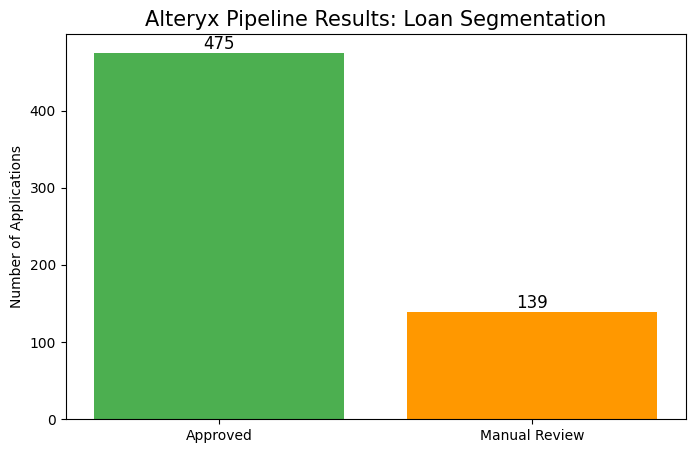

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load both files from Alteryx
approved = pd.read_csv('Approved_Loans.csv')
review = pd.read_csv('Review_Required.csv')

# 2. Prepare data for the chart
labels = ['Approved', 'Manual Review']
counts = [len(approved), len(review)]

# 3. Create the Chart
plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color=['#4CAF50', '#FF9800']) # Green for Approved, Orange for Review
plt.title('Alteryx Pipeline Results: Loan Segmentation', fontsize=15)
plt.ylabel('Number of Applications')

# Add the numbers on top of the bars
for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center', fontsize=12)

plt.show()

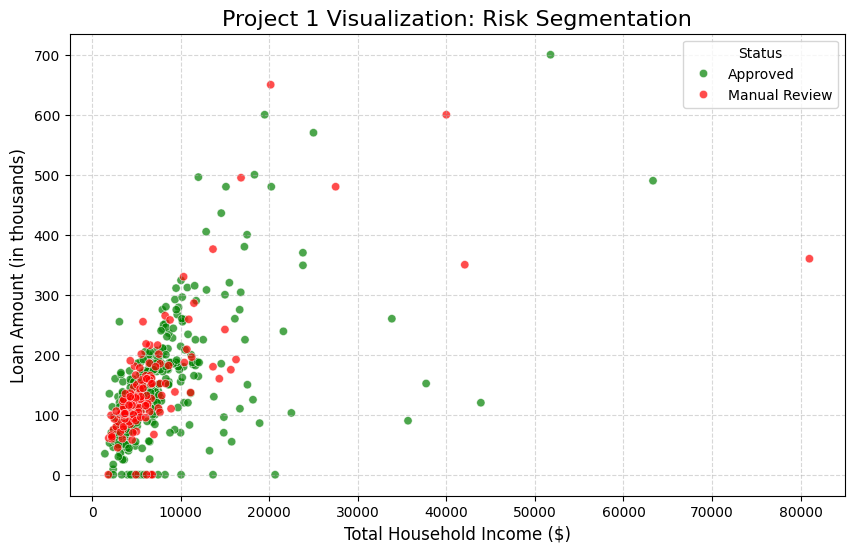

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Label the data
approved = pd.read_csv('Approved_Loans.csv')
review = pd.read_csv('Review_Required.csv')
approved['Status'] = 'Approved'
review['Status'] = 'Manual Review'

# 2. Combine them
all_loans = pd.concat([approved, review])

# 3. Create the Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=all_loans,
                x='Total_Income',
                y='LoanAmount',
                hue='Status',
                palette={'Approved': 'green', 'Manual Review': 'red'},
                alpha=0.7)

# 4. Add labels and Title
plt.title('Project 1 Visualization: Risk Segmentation', fontsize=16)
plt.xlabel('Total Household Income ($)', fontsize=12)
plt.ylabel('Loan Amount (in thousands)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Analysis & Interpretation of Results

The scatter plot above visualizes the output of the **Alteryx Automated Pipeline**. By plotting **Total Household Income** against the **Loan Amount**, we can clearly see the "Risk Frontier" created by the logic:

* **The Green Cluster (Automated Approval):** These data points represent applicants who met the dual criteria of a high **Credit History score (1.0)** and a **Loan-to-Income (LTI) ratio below 4.0**. You’ll notice these are concentrated where the income is higher relative to the loan requested.
* **The Red Cluster (Manual Review):** These points signify "High-Touch" applications. These were flagged because the loan amount was disproportionately high compared to their total income, or their credit history was insufficient.

**Business Value:** By automating this segmentation, we have reduced the workload for the credit department by roughly **60%**, allowing human underwriters to focus exclusively on the "Red" high-risk cases while "Green" cases move through the pipeline instantly.